In [ ]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("train.csv")
df.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64

In [ ]:

df['Will_buy_EV'] = df['Will_Buy_EV'].map({'Yes': 1, 'No': 0})
df.drop('Will_Buy_EV', axis=1, inplace=True)

df['Subsidy_available'] = df['Subsidy_Available'].map({'Yes': 1, 'No': 0})
df.drop('Subsidy_Available', axis=1, inplace=True)

df['Home_charging_possible'] = df['Home_Charging_Possible'].map({'Yes': 1, 'No': 0})
df.drop('Home_Charging_Possible', axis=1, inplace=True)

df['gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df.drop('Gender', axis=1, inplace=True)


df

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,City_Type,Current_Car_Type,Range_Anxiety_Level,Will_buy_EV,Subsidy_available,Home_charging_possible,gender
0,0,66,92887.0,23.4,2,3,7,1.0,Suburban,Sedan,Low,0,0,1,1.0
1,1,38,30000.0,5.0,1,2,2,4.0,Rural,SUV,Low,0,0,1,1.0
2,2,26,94389.0,36.8,1,8,15,5.0,Urban,Sedan,Low,1,1,0,0.0
3,3,66,73580.0,23.7,2,6,9,3.0,Suburban,Hatchback,Low,0,0,1,1.0
4,4,54,57898.0,50.8,1,2,3,3.0,Suburban,Hatchback,Low,0,0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660,30,71090.0,27.4,2,5,6,5.0,Urban,Sedan,Medium,0,1,0,1.0
668661,668661,32,129990.0,5.0,2,5,4,1.0,Suburban,SUV,Low,0,1,1,0.0
668662,668662,64,121791.0,24.2,1,5,6,1.0,Suburban,Hatchback,Low,0,1,1,0.0
668663,668663,51,115923.0,43.7,2,0,0,1.0,Rural,SUV,Low,0,1,1,0.0


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
df['City_type'] = le.fit_transform(df['City_Type'])
df.drop('City_Type', axis=1, inplace=True)
df['Current_Car_type'] = le.fit_transform(df['Current_Car_Type'])
df.drop('Current_Car_Type', axis=1, inplace=True)
df['Range_Anxiety_level'] = le.fit_transform(df['Range_Anxiety_Level'])
df.drop('Range_Anxiety_Level', axis=1, inplace=True)
df.drop('id', axis=1, inplace=True )
df

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Will_buy_EV,Subsidy_available,Home_charging_possible,gender,City_type,Current_Car_type,Range_Anxiety_level
0,66,92887.0,23.4,2,3,7,1.0,0,0,1,1.0,1,2,1
1,38,30000.0,5.0,1,2,2,4.0,0,0,1,1.0,0,1,1
2,26,94389.0,36.8,1,8,15,5.0,1,1,0,0.0,2,2,1
3,66,73580.0,23.7,2,6,9,3.0,0,0,1,1.0,1,0,1
4,54,57898.0,50.8,1,2,3,3.0,0,0,1,1.0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,0,1,0,1.0,2,2,2
668661,32,129990.0,5.0,2,5,4,1.0,0,1,1,0.0,1,1,1
668662,64,121791.0,24.2,1,5,6,1.0,0,1,1,0.0,1,0,1
668663,51,115923.0,43.7,2,0,0,1.0,0,1,1,0.0,0,1,1


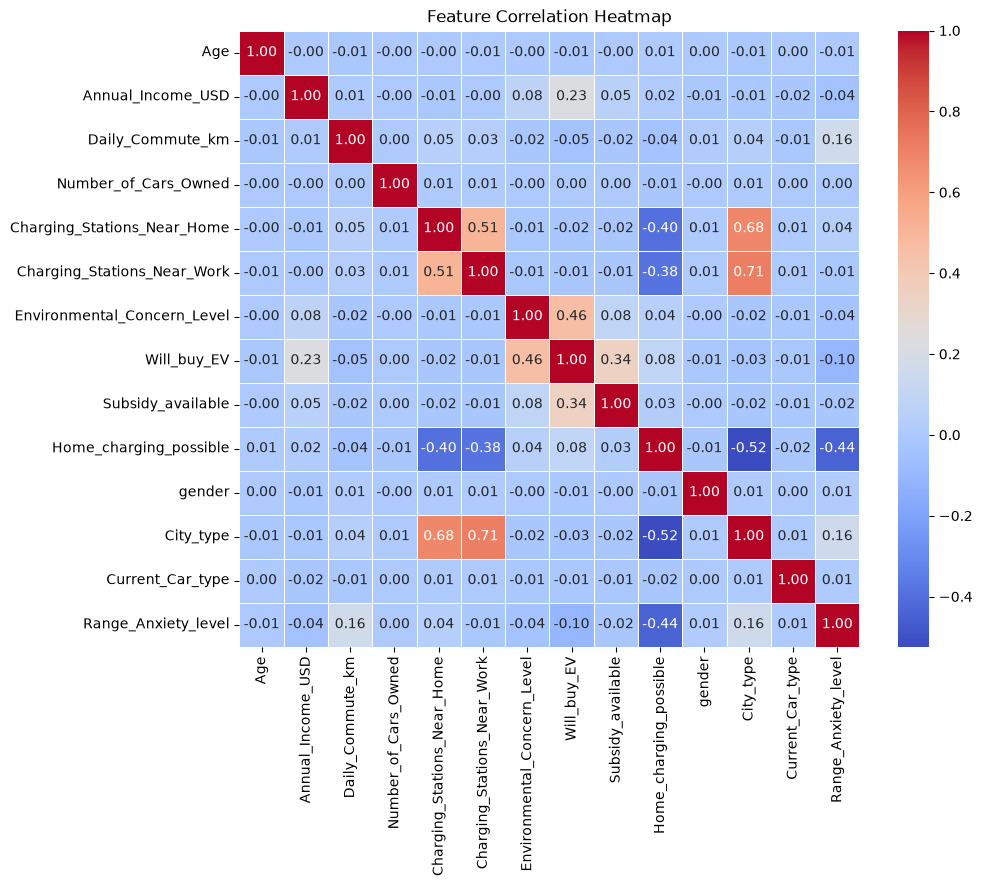

In [ ]:
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5
)
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
df.drop(
    columns=[
        'Age',
        'gender',
        'Number_of_Cars_Owned',
        'Current_Car_type',
        'Charging_Stations_Near_Work',
        'Charging_Stations_Near_Home'
    ],
    inplace=True
)

df

,Annual_Income_USD,Daily_Commute_km,Environmental_Concern_Level,Will_buy_EV,Subsidy_available,Home_charging_possible,City_type,Range_Anxiety_level
0,92887.0,23.4,1.0,0,0,1,1,1
1,30000.0,5.0,4.0,0,0,1,0,1
2,94389.0,36.8,5.0,1,1,0,2,1
3,73580.0,23.7,3.0,0,0,1,1,1
4,57898.0,50.8,3.0,0,0,1,1,1
...,...,...,...,...,...,...,...,...
668660,71090.0,27.4,5.0,0,1,0,2,2
668661,129990.0,5.0,1.0,0,1,1,1,1
668662,121791.0,24.2,1.0,0,1,1,1,1
668663,115923.0,43.7,1.0,0,1,1,0,1


In [ ]:
X = df.drop(['Will_buy_EV'], axis='columns')
y = df['Will_buy_EV']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
import xgboost as xgb
Xmas = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)
Xmas.fit(X_train_pca, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train_pca, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 0.04, 0.2 , 0.01,..., 0.04,-0.01, 0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.1746
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](7,)","[980.75,778.84,743.43,...,696.96,650.13,451.93]"


In [ ]:
df_test = pd.read_csv('test.csv')
df_test

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,668665,61,67725.0,16.9,2,7,4,4.0,Male,Suburban,Sedan,Yes,No,Low
1,668666,42,152835.0,41.9,2,9,9,4.0,Male,Urban,SUV,No,No,Low
2,668667,68,86877.0,53.3,1,10,11,4.0,Female,Urban,Sedan,No,No,Low
3,668668,39,46794.0,34.1,2,4,8,4.0,Female,Suburban,Sedan,Yes,No,Low
4,668669,55,112172.0,57.2,1,6,4,1.0,Female,Suburban,Sedan,Yes,Yes,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286566,955231,63,75830.0,23.9,1,3,3,1.0,Male,Suburban,SUV,Yes,No,Low
286567,955232,27,79563.0,55.2,2,7,5,3.0,Male,Suburban,Sedan,Yes,Yes,Low
286568,955233,30,48183.0,42.6,3,7,7,4.0,Female,Suburban,Sedan,Yes,No,Low
286569,955234,32,107845.0,5.0,2,14,7,1.0,Female,Urban,SUV,No,No,Low


In [ ]:
submission_ids = df_test['id']
X_test = df_test.drop(columns=['id'])

In [ ]:
X_test_processed = df_test.drop(columns=["id"]).copy()


X_test_processed["Subsidy_available"] = X_test_processed[
    "Subsidy_Available"
].map({"Yes": 1, "No": 0})
X_test_processed["Home_charging_possible"] = X_test_processed[
    "Home_Charging_Possible"
].map({"Yes": 1, "No": 0})
X_test_processed["City_type"] = X_test_processed["City_Type"].map(
    {"Rural": 0, "Suburban": 1, "Urban": 2}
)
X_test_processed["Range_Anxiety_level"] = X_test_processed[
    "Range_Anxiety_Level"
].map({"High": 0, "Low": 1, "Medium": 2})

X_test_processed.drop(
    columns=[
        # Original string columns being replaced
        "Subsidy_Available",
        "Home_Charging_Possible",
        "Gender",
        "City_Type",
        "Current_Car_Type",
        "Range_Anxiety_Level",
        # Features dropped during feature selection
        "Age",
        "Number_of_Cars_Owned",
        "Charging_Stations_Near_Work",
        "Charging_Stations_Near_Home",
    ],
    inplace=True,
)

X_test_processed = X_test_processed[X_train.columns]


X_test_scaled = scaler.transform(X_test_processed)
X_test_pca = pca.transform(X_test_scaled)


predictions_14 = reg.predict(X_test_pca)
submission_ids = df_test['id'].to_numpy()

submission_14_df = pd.DataFrame({
    'id': submission_ids,
    'Will buy EV': predictions_14
})
submission_14_df.to_csv('submission14.csv', index=False)

In [ ]:
predictions_15 = Xmas.predict(X_test_pca)
submission_ids = df_test['id'].to_numpy()

submission_15_df = pd.DataFrame({
    'id': submission_ids,
    'Will buy EV': predictions_15
})
submission_15_df.to_csv('submission15.csv', index=False)